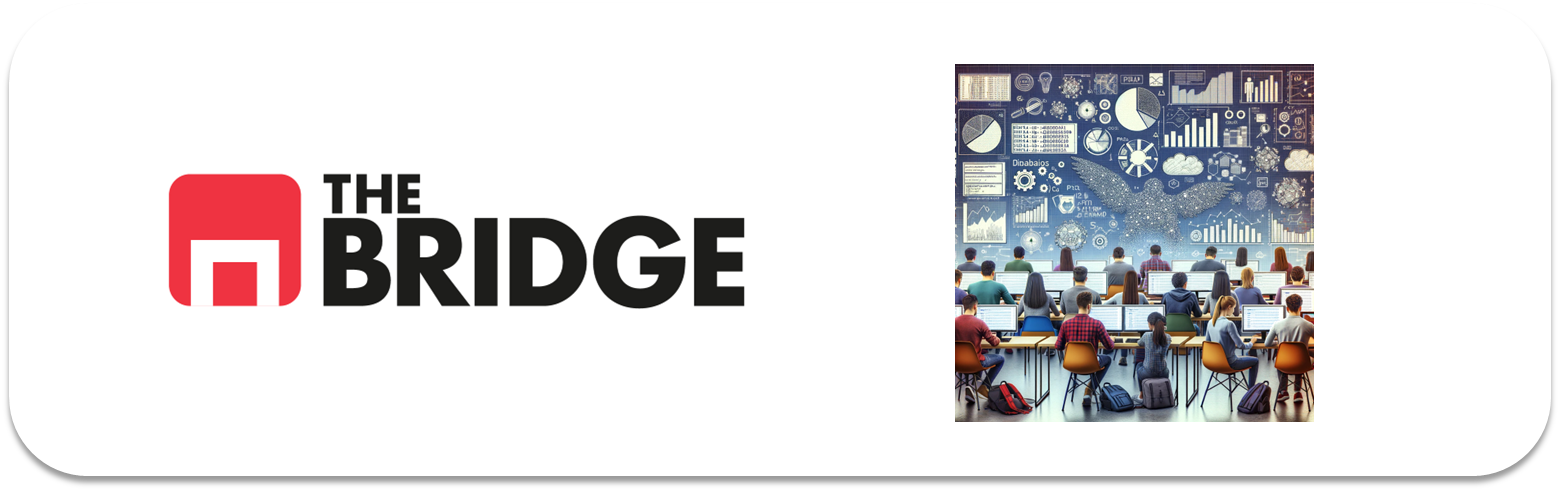

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [140]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bcviz

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



### **1. Carga del dataset del Titanic**

In [141]:
df = pd.read_csv('data/titanic.csv')
df.head(20) # Cargamos 20 registros del dataset del Titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [142]:
df.info() # Aquí vemos el volumen de datos nulos y el tipo de variables del dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


### **2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones**

In [143]:
# Extraemos el volumen de nulos por cada una de las variables. 
# Y se puede extraer algunas conclusiones interesantes
# 1. deck es una variable con el 77% de valores nulos, no tiene sentido para el modelo. 
# 2. age tiene un 20% de valores nulos, pero tiene sentido resolver esos nulos con imputaciones. 
# 3. embarked y embarked_town tienen un 0.22% de nulos, que es una cifra muy baja. 

nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)
print(porcentaje_nulos)

survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64


#### Elementos clave en la eliminación de variables e imputaciones: 

1. Eliminamos la variable `alive`porque vamos a usar `survived`como la variable target. La dos son iguales. 
2. La variable `deck` la eliminamos por su enorme volumen de nulos. 
3. La variable `class` es la mims que `pclass`. Nos quedamos con la segunda. 
4. `embark_town`es la misma que `embarked`. Nos quedamos con la segunda. 
5. La variable `who`la eliminamos también porque nos vamos a quedar con `sex`y `age`.
6. `adult_male` mismo caso que `who`. Todas estas variables que son similares puede generar colinealidad. Sobreponderar los mismos datos en el modelo.

In [144]:
df_titanic = df.copy() # Creamos una copia del dataset. 

In [145]:
# Creamos una variable con todas las columnas a eliminar. 
# Y eliminamos esas variables en el dataset copia df_titanic.
# Mostramos 20 registros del nuevo dataset sin las columnas eliminadas

col_deleted = ['alive', 'class', 'embark_town', 'deck', 'who', 'adult_male']
df_titanic = df_titanic.drop(columns=col_deleted)
df_titanic.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True
5,0,3,male,NaN,0,0,8.4583,Q,True
6,0,1,male,54.0,0,0,51.8625,S,True
7,0,3,male,2.0,3,1,21.0750,S,False
8,1,3,female,27.0,0,2,11.1333,S,False
9,1,2,female,14.0,1,0,30.0708,C,False


### **3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.**

In [146]:
# Analizamos un poco la distribución porcentual de la variable target. En este caso suvived. 
# Hay un 61% de personas que fallecieron en el Titanic. Y un 39% que sobrevivieron. 

df_titanic.survived.value_counts(True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

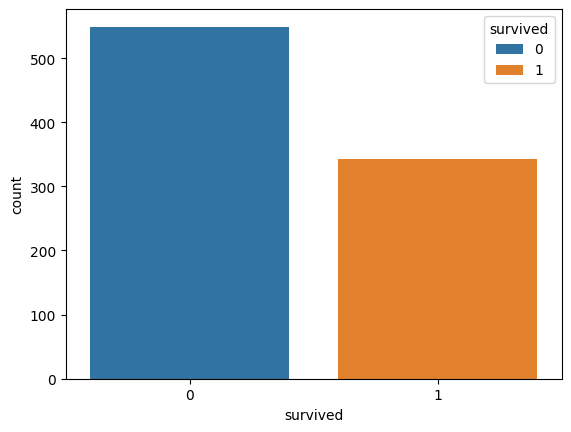

In [147]:
# Mostramos un gráfico de barras para visualizar la proporción de la variables

sns.countplot(x = "survived", data = df_titanic, hue = "survived"); 

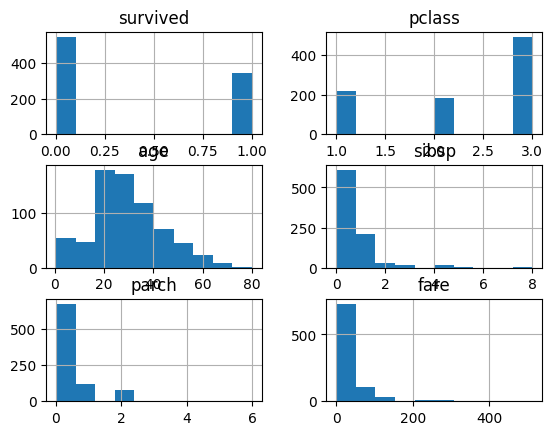

In [148]:
df_titanic.hist(); 

# Aquí podemos ver la distribución de todas las variables que tenemos en el dataset final
# Lógicamente hay variables con una distribución que va a necesitar que las normalicemos. 

### **4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.**

In [149]:
# Separamos train y test con variable X (todas las variables menos el target) e y con la variable target. 
# En este caso la variable target es survived
# Al hacer el split me da error porque embarked tiene nulos. 
# Lo primero que hago es dropar todos los valores nulos de esa variable

df_titanic = df_titanic.dropna(subset=['embarked']) # Aquí sacamos todos los nulos de embarked, que eran un 0.22% solo.


In [150]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       712 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 63.4+ KB


In [151]:
# Separamos el conjunto de datos X con todas las variables menos el target y la variable target
# Split usando stratify para que los datos de entrenamiento y test mantengan porcentaje de reparto similiares en los datos del modelo
# Ya vimos que esto es relevante porque la ciudad de embarque alteraba en exceso el % de superviviencia
# Si al extraer datos para entrenamiento y test no mantengo esa proporción, el modelo no será bueno

X = df_titanic.drop(['survived'], axis=1)
y = df_titanic['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=df_titanic['embarked'], random_state=42) 

In [152]:
# Creo un diccionario con el reparto porcentual de embarcados por ciudades en el dataset original, datos en entrenamiento y datos de test
# La idea era hacer la separación de train y set con un volumen de datos similares al original

dict_table = pd.DataFrame({
    'Volumen de embarcados en datos originales': X.embarked.value_counts(normalize=True),
    'Volumen de embarcados en datos de entrenamiento':X_train.embarked.value_counts(normalize=True),
    'Volumen de embarcados en datos de test':X_test.embarked.value_counts(normalize=True)
})

print(dict_table)



          Volumen de embarcados en datos originales  \
embarked                                              
S                                          0.724409   
C                                          0.188976   
Q                                          0.086614   

          Volumen de embarcados en datos de entrenamiento  \
embarked                                                    
S                                                0.724332   
C                                                0.188467   
Q                                                0.087201   

          Volumen de embarcados en datos de test  
embarked                                          
S                                       0.724719  
C                                       0.191011  
Q                                       0.084270  


### **6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test**

In [153]:
# La variable age es la única que sigue teniendo nulos y podemos solucionarlo usando la media para asignar valores a los nulos
# La media la aplico en los datos de entrenamiento y test a partir de los datos de entrenamiento

age_train = X_train['age'].mean()
X_train['age'] = X_train['age'].fillna(age_train)
X_test['age'] = X_test['age'].fillna(age_train)

In [154]:
# Comprobamos si hay valores nulos aún en los datos de entrenamiento

X_train.info() # No hay nulos, hemos aplicado a todos los valores la media de edad de train

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 46 to 253
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    711 non-null    int64  
 1   sex       711 non-null    object 
 2   age       711 non-null    float64
 3   sibsp     711 non-null    int64  
 4   parch     711 non-null    int64  
 5   fare      711 non-null    float64
 6   embarked  711 non-null    object 
 7   alone     711 non-null    bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 45.1+ KB


In [155]:
# Comprobamos si hay valores nulos aún en los datos de test

X_test.info() # No hay nulos, hemos aplicado a todos los valores nulos la media de edad de train


<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, 223 to 142
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    178 non-null    int64  
 1   sex       178 non-null    object 
 2   age       178 non-null    float64
 3   sibsp     178 non-null    int64  
 4   parch     178 non-null    int64  
 5   fare      178 non-null    float64
 6   embarked  178 non-null    object 
 7   alone     178 non-null    bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 11.3+ KB


### **7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.**


In [156]:
# Instancio un df con los datos de entrenamiento y le echo un vistazo
# Para el EDA tenemos que incluir de nuevo en el dataset la variable survived porque estaba separada tras el split

df_eda = X_train.copy()
df_eda["survived"] = y_train.copy()
df_eda.head(20) 

,pclass,sex,age,sibsp,parch,fare,embarked,alone,survived
46,3,male,29.710454,1,0,15.5000,Q,False,0
230,1,female,35.000000,1,0,83.4750,S,False,1
657,3,female,32.000000,1,1,15.5000,Q,False,0
888,3,female,29.710454,1,2,23.4500,S,False,0
809,1,female,33.000000,1,0,53.1000,S,False,1
679,1,male,36.000000,0,1,512.3292,C,False,1
64,1,male,29.710454,0,0,27.7208,C,True,0
71,3,female,16.000000,5,2,46.9000,S,False,0
299,1,female,50.000000,0,1,247.5208,C,False,1
824,3,male,2.000000,4,1,39.6875,S,False,0


In [157]:
df_eda.describe() # Aquí vemos un poco los valores descriptivos de las variables de los datos de entrenamiento

,pclass,age,sibsp,parch,fare,survived
count,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000
mean,2.340366,29.710454,0.499297,0.368495,31.646823,0.381153
std,0.827036,13.043642,0.981340,0.763105,51.212661,0.486012
min,1.000000,0.670000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800,0.000000
50%,3.000000,29.710454,0.000000,0.000000,14.000000,0.000000
75%,3.000000,35.000000,1.000000,0.000000,30.285400,1.000000
max,3.000000,80.000000,8.000000,5.000000,512.329200,1.000000


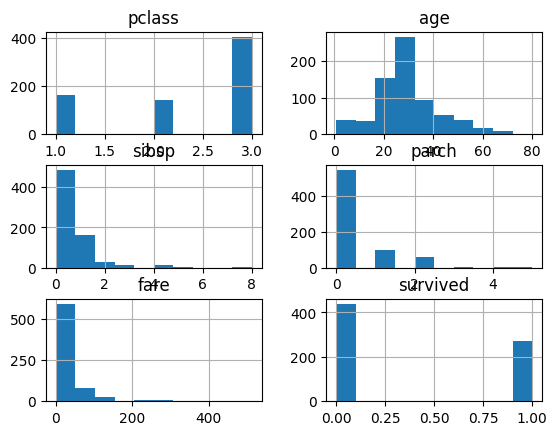

In [158]:
df_eda.hist(); 

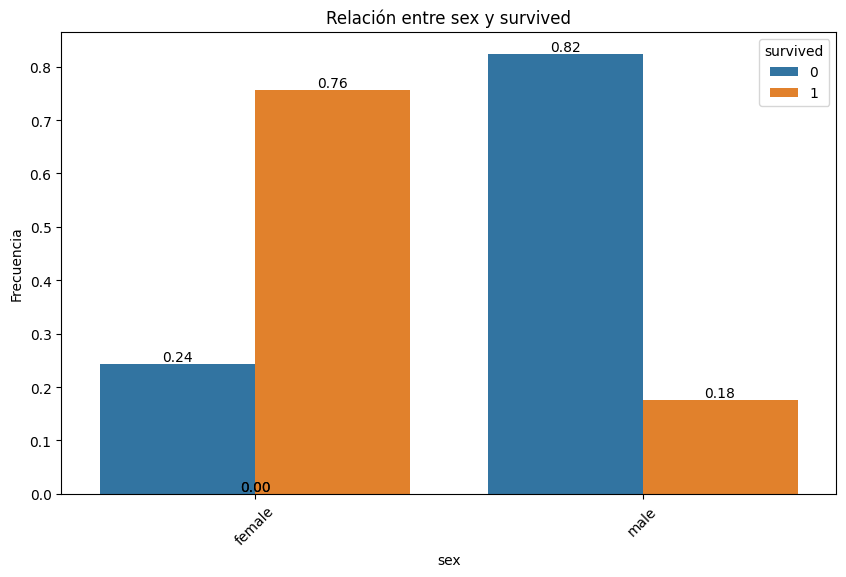

In [159]:
# Aquí se puede ver la relación entre supervivientes y sexo dentro de nuestro dataset de entrenamiento

bcviz.plot_categorical_relationship_fin(df_eda, 'sex', 'survived', relative_freq=True, show_values=True)

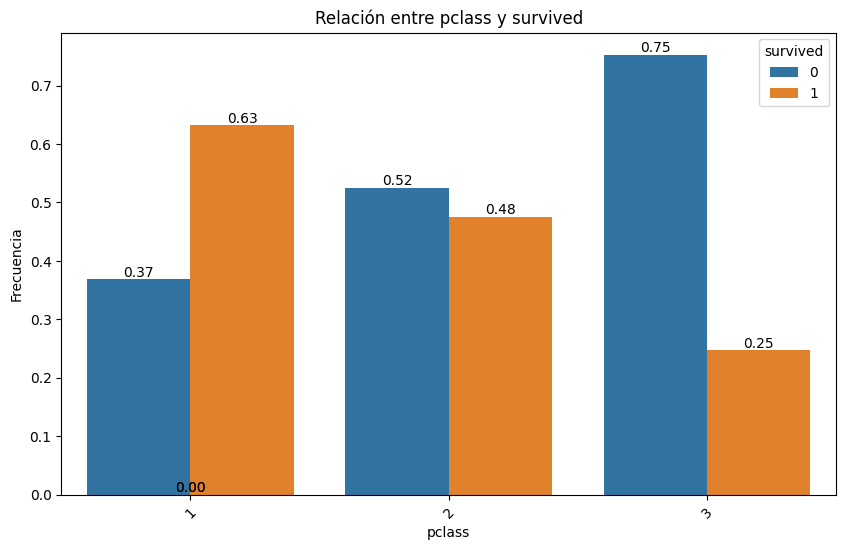

In [160]:
# Y aquí la relación de superviviencia en cada una de las clases en el dataset de entrenamiento

bcviz.plot_categorical_relationship_fin(df_eda, 'pclass', 'survived', relative_freq=True, show_values=True)

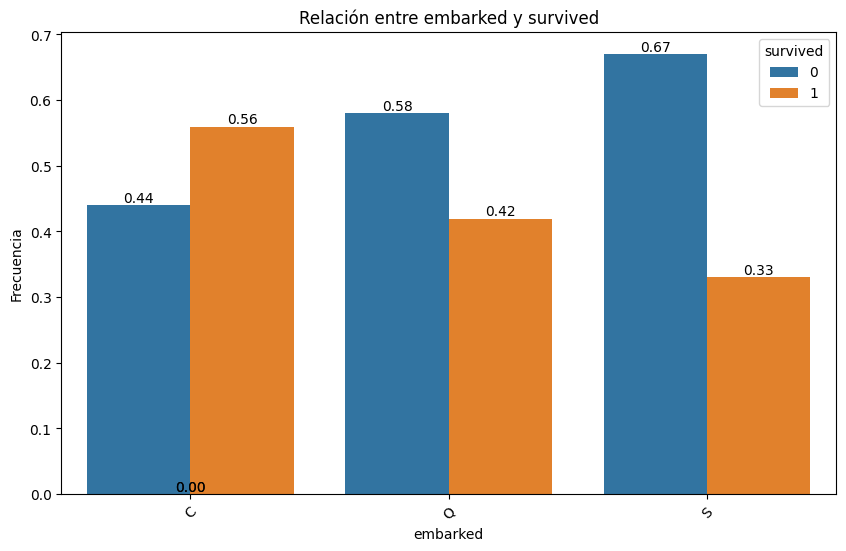

In [161]:
# Y aquí la relación de superviviencia en cada una de las ciudades de embarque en el dataset de entrenamiento

bcviz.plot_categorical_relationship_fin(df_eda, 'embarked', 'survived', relative_freq=True, show_values=True)

In [162]:
# Correlaciones con el coeficiente de correlación de Pearson
# Solo incluimos columnas numéricas, tenemos que sacar sex porque da error 
# Al final se ven varias cosas muy claras: 
# 1. Correlación negativa muy fuerte entre clase y supervivencia: a clases más alta (número bajo [1, 2 y 3], más supervivencia)
# 2. Correlación positiva muy fuerte entre precio del billete y supervivencia: a más precio del billete, más supervivencia
# 3. El resto de correlaciones con otra variables son débiles 

cols_num = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr = df_eda[cols_num].corr()['survived'].drop('survived').sort_values(key=abs, ascending=False)

print(corr)


pclass   -0.333723
fare      0.268742
parch     0.091666
age      -0.047382
sibsp    -0.006820
Name: survived, dtype: float64


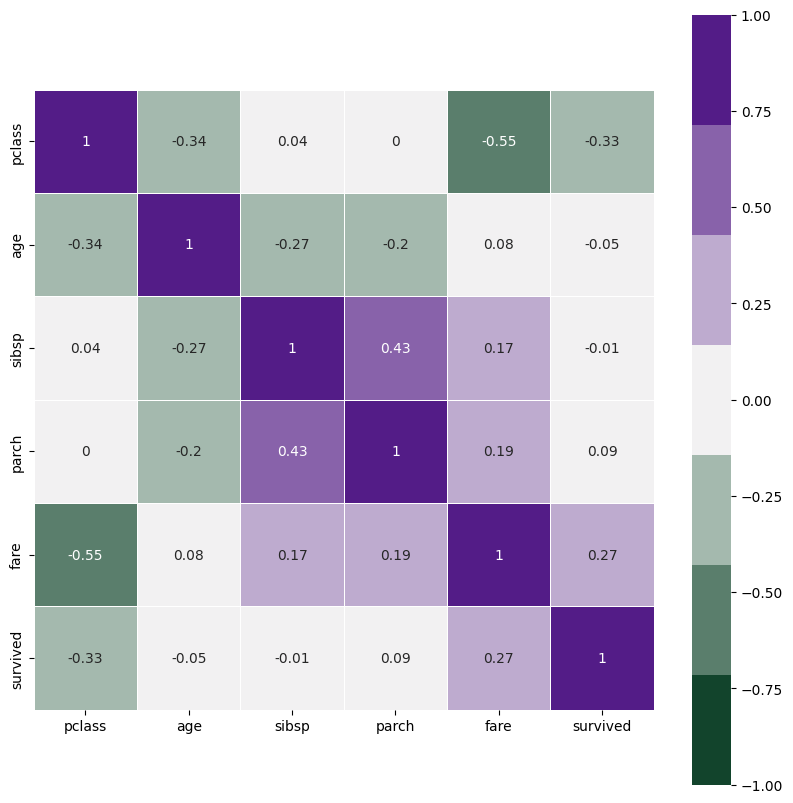

In [163]:
# Mostramos un heatmap solo con la variables numéricas del dataset de entrenamiento
# Antes veíamos la relación entre variables numérica y target. 
# Aquí se ve la relación con el target pero además entre todas ellas entre sí. 
# Se puede ver muy fácil la relación inversa entre clase y precio de billete (-0.55) o entre clase y edad (gente más joven en tercera)

plt.figure(figsize=(10,10))
sns.heatmap(np.round(df_eda[cols_num].corr(), 2),
            vmin=-1,
            vmax=1,
            annot=True,
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
            square=True,
            linewidths=.5);

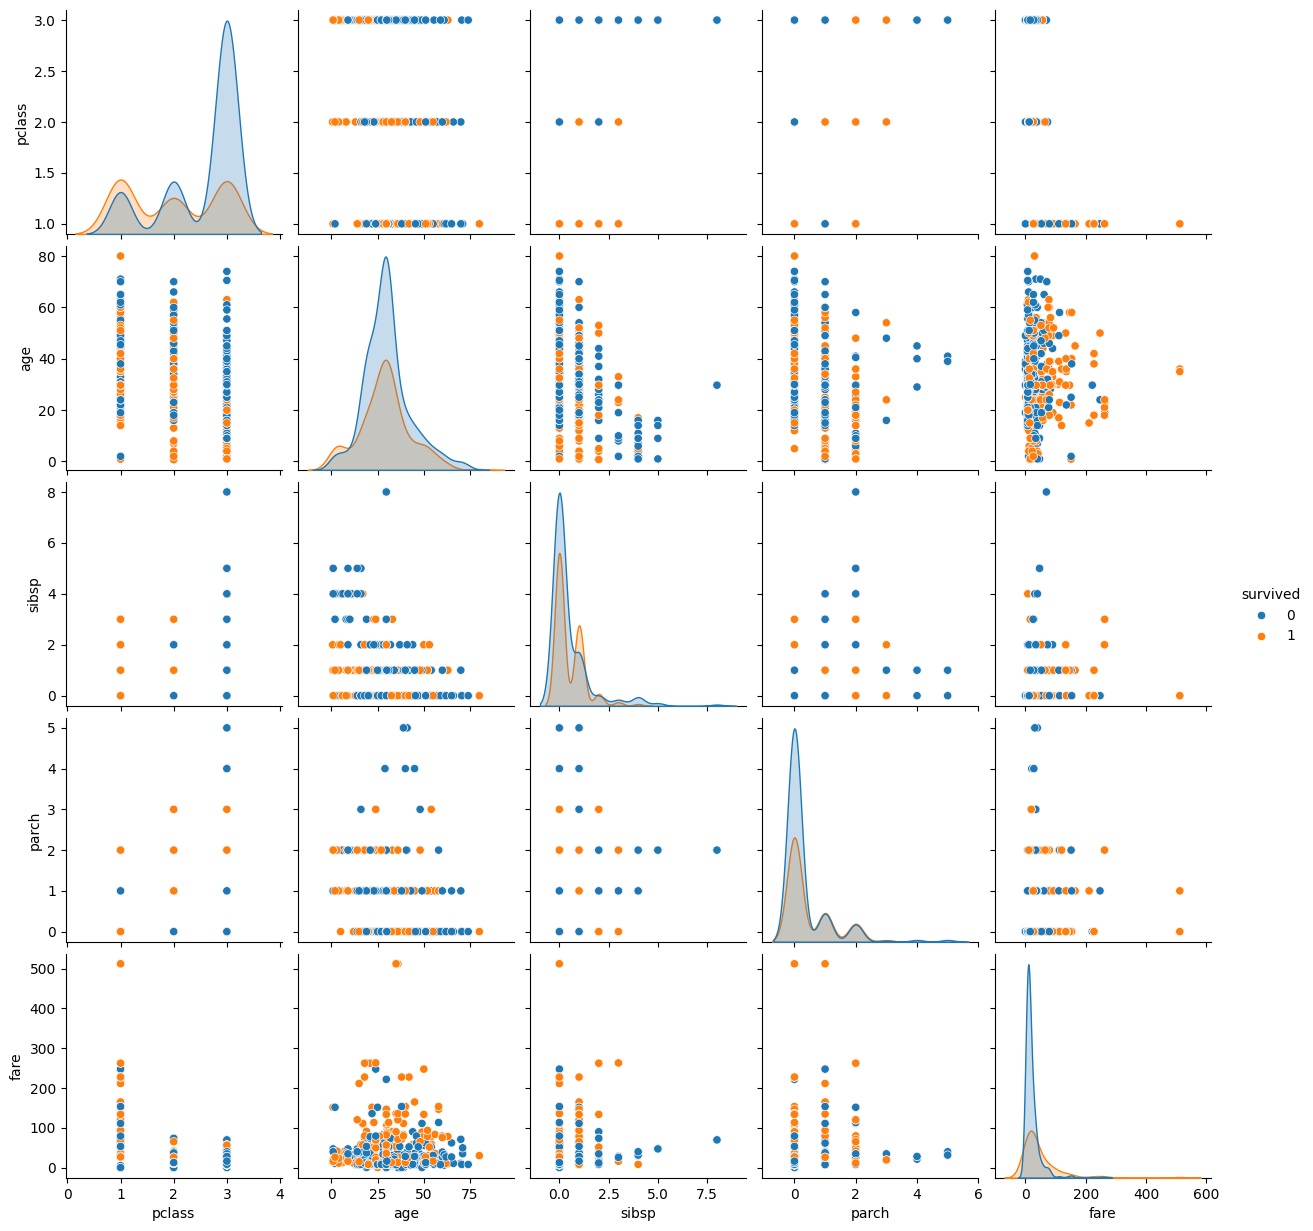

In [164]:
sns.pairplot(df_eda[cols_num], hue = "survived") # Misma relación de variables con un pairplot

#### Se pedía en el ejercicio elegir con qué variables nos quedaríamos para el modelo: 

1. `sex`: vimos en el eda que las mujeres tenían porcentaje de supervivencia alto. Es relevante para el modelo. 
2. `age`: edad es otra variable que puede tener relevancia por los niños y la alta mortalidad en hombres jóvenes. Entra en el modelo. 
3. `pclass`: tiene una correlación negativa muy fuerte. Entra en el modelo. 
4. `fare`: correlación positiva muy fuerte. Relevante para el modelo. 
5. El resto de variables tienen menos incidencia en la supervivencia, pero no las vamos a descartar. Las usamos todas. 

### **8. Trata las variables para que funcionen lo mejor posible en el modelo.**


array([[<Axes: title={'center': 'pclass'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'sibsp'}>,
        <Axes: title={'center': 'parch'}>],
       [<Axes: title={'center': 'fare'}>, <Axes: >]], dtype=object)

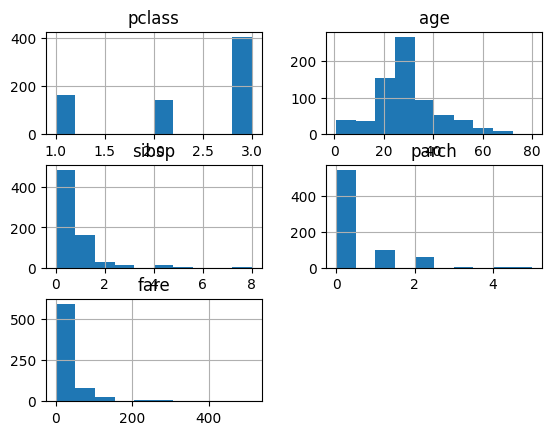

In [165]:
X_train.hist()

In [166]:
X_train.describe()

,pclass,age,sibsp,parch,fare
count,711.000000,711.000000,711.000000,711.000000,711.000000
mean,2.340366,29.710454,0.499297,0.368495,31.646823
std,0.827036,13.043642,0.981340,0.763105,51.212661
min,1.000000,0.670000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800
50%,3.000000,29.710454,0.000000,0.000000,14.000000
75%,3.000000,35.000000,1.000000,0.000000,30.285400
max,3.000000,80.000000,8.000000,5.000000,512.329200


In [167]:
# Aquí se convinan variables con rangos bajos (pclass, sibsp y parch), con variables con rangos altos (age y fare)
# Escalar las variables con rangos altos va a permitir que la diferencia de escala no afecte negativamente al modelo

features = ['age', 'fare']

scaler = StandardScaler()
X_train[features] = scaler.fit_transform(X_train[features])
X_test[features] = scaler.transform(X_test[features])

In [168]:
X_train.describe()

,pclass,age,sibsp,parch,fare
count,711.000000,7.110000e+02,711.000000,711.000000,7.110000e+02
mean,2.340366,1.748875e-17,0.499297,0.368495,-3.747588e-17
std,0.827036,1.000704e+00,0.981340,0.763105,1.000704e+00
min,1.000000,-2.227974e+00,0.000000,0.000000,-6.183842e-01
25%,2.000000,-5.915435e-01,0.000000,0.000000,-4.640990e-01
50%,3.000000,0.000000e+00,0.000000,0.000000,-3.448219e-01
75%,3.000000,4.058123e-01,1.000000,0.000000,-2.660242e-02
max,3.000000,3.858198e+00,8.000000,5.000000,9.392614e+00


array([[<Axes: title={'center': 'pclass'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'sibsp'}>,
        <Axes: title={'center': 'parch'}>],
       [<Axes: title={'center': 'fare'}>, <Axes: >]], dtype=object)

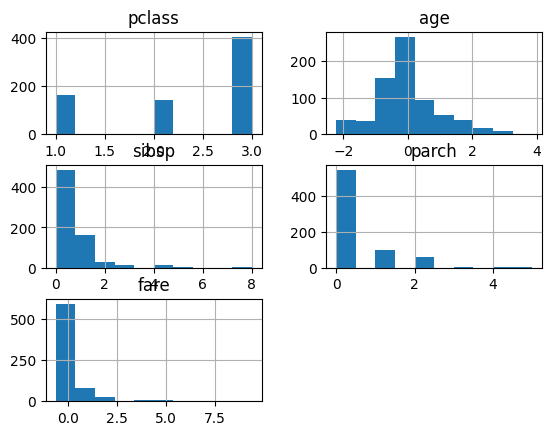

In [169]:
X_train.hist() # Aquí ya se puede ver cómo age y fare son variable en rangos comparativos con las demás variables

### **9. Construye un modelo de regresión logística.**

In [ ]:
# El crear el modelo me da error porque la variable sex la tenemos que pasar a numérica 
# Lo mismo sucede con alone, que debemos pasarla de variable booleana a numérica
# La variable embarked también me dad error y he pedido ayuda a ModoIA de Google para hacer un One-Hot-Encoding 

sex_map = {'female': 0, 'male': 1}
X_train['sex'] = X_train['sex'].map(sex_map)
X_test['sex'] = X_test['sex'].map(sex_map)

X_train['alone'] = X_train['alone'].astype(int)
X_test['alone'] = X_test['alone'].astype(int)

X_train = pd.get_dummies(X_train, columns=['embarked'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['embarked'], drop_first=True, dtype=int)


In [171]:
X_train.info() # Ahí ya tenemos las variables sex y alone como variables numéricas y no categórica y booleana

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 46 to 253
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      711 non-null    int64  
 1   sex         711 non-null    int64  
 2   age         711 non-null    float64
 3   sibsp       711 non-null    int64  
 4   parch       711 non-null    int64  
 5   fare        711 non-null    float64
 6   alone       711 non-null    int64  
 7   embarked_Q  711 non-null    int64  
 8   embarked_S  711 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 55.5 KB


In [172]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter = 1000, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### **10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.**


In [173]:
print(log_reg.coef_)
print(log_reg.intercept_)
print(log_reg.classes_)

[[-0.88010429 -2.61089138 -0.38505145 -0.48292458 -0.27767809  0.17819989
  -0.56375398  0.14813086 -0.27272578]]
[3.9760632]
[0 1]


In [185]:
# La variable sex fue claramente la determinante a la hora de sobrevivir en el Titanic. 
# pclass también fue muy relevante: altos índices de mortalidad en tercera clase. 


intercept = log_reg.intercept_
coefs = log_reg.coef_.ravel()

features = pd.DataFrame(coefs, X_train.columns, columns=['coefficient']).copy()
features['coefficient'] = np.abs(features['coefficient'])

features.sort_values('coefficient', ascending=False).head()

,coefficient
sex,2.610891
pclass,0.880104
alone,0.563754
sibsp,0.482925
age,0.385051


### **11. Procesa el dataset de Test para que puedas usarlo en la evaluación**


In [176]:
X_test = X_test[X_train.columns].copy()

In [177]:
acc_train = round(accuracy_score(log_reg.predict(X_train), y_train), 3)
acc_test = round(accuracy_score(log_reg.predict(X_test), y_test), 3)

print("Accuracy train:", acc_train)
print("Accuracy test:", acc_test)

Accuracy train: 0.814
Accuracy test: 0.775


In [178]:
y_train.value_counts(True)

survived
0    0.618847
1    0.381153
Name: proportion, dtype: float64

In [179]:
y_test.value_counts(True)

survived
0    0.61236
1    0.38764
Name: proportion, dtype: float64

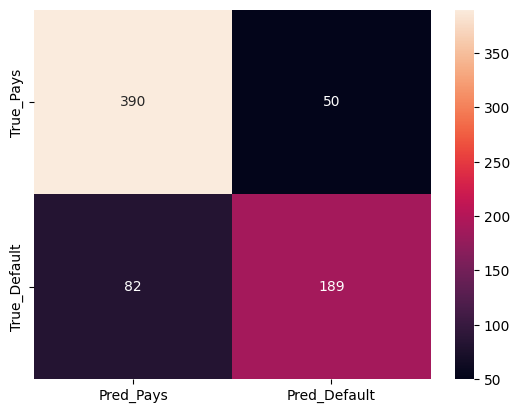

In [187]:
c_matrix = confusion_matrix(y_train, log_reg.predict(X_train))

c_matrix_df = pd.DataFrame(c_matrix, columns = ['Pred_Pays', 'Pred_Default'],
                          index = ['True_Pays', 'True_Default'])

sns.heatmap(c_matrix_df, annot=True, fmt='g');